# 02 — EDA

Ноутбук исследует значения датасета: target, пропуски, дубликаты, числовые и категориальные признаки. Повторно используемая логика импортируется из `src/ml_project`; определения функций в notebook не дублируются.

Конфигурация файлов, key, target и описаний столбцов хранится централизованно в `src/ml_project/config.py`.

Типы признаков не определяются автоматически по dtype: явная схема хранится в `FEATURE_GROUPS` внутри `src/ml_project/config.py`.

In [3]:
from pathlib import Path
import sys

from IPython.display import display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").exists() and (candidate / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import (
    DataCatalog,
    DatasetProfiler,
    MarkdownDocument,
    build_data_blocks,
    build_eda_blocks,
    validate_feature_groups,
)
from ml_project.config import (
    DATASETS,
    FEATURE_GROUPS,
    FIELD_DESCRIPTIONS,
    INFERENCE_DATASET,
    KEY,
    RAW_DIR,
    TARGET,
    TRAIN_DATASET,
)

print(f"Корень проекта: {PROJECT_ROOT}")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# В текущем окружении включите после проверки рендеринга matplotlib.
ENABLE_PLOTS = True

Корень проекта: D:\Anton_ML\obsidian\Titanik-ML-project


In [4]:
import importlib
import ml_project.config as project_config

# Перечитываем config.py, чтобы изменения групп применялись без restart kernel.
project_config = importlib.reload(project_config)
DATASETS = project_config.DATASETS
FEATURE_GROUPS = project_config.FEATURE_GROUPS
INFERENCE_DATASET = project_config.INFERENCE_DATASET
KEY = project_config.KEY
RAW_DIR = project_config.RAW_DIR
TARGET = project_config.TARGET
TRAIN_DATASET = project_config.TRAIN_DATASET

catalog = DataCatalog(PROJECT_ROOT, RAW_DIR, DATASETS)
catalog.validate()
datasets = catalog.load_all()

# В EDA участвуют только обучающие и inference-данные.
# Служебные файлы остаются в DataCatalog, но не входят в профили и отчёты.
EDA_ROLES = {"train", "inference"}
eda_datasets = {
    name: frame
    for name, frame in datasets.items()
    if DATASETS[name].get("role") in EDA_ROLES
}

profiles = {
    name: DatasetProfiler(
        frame,
        name=name,
        key=KEY,
        target=TARGET if name == TRAIN_DATASET else None,
    )
    for name, frame in eda_datasets.items()
}
if TRAIN_DATASET not in profiles:
    raise KeyError(f"Train dataset {TRAIN_DATASET!r} is unavailable for EDA.")

train_profile = profiles[TRAIN_DATASET]
test_profile = profiles.get(INFERENCE_DATASET)
feature_groups = validate_feature_groups(
    train_profile.df,
    FEATURE_GROUPS,
    target=TARGET,
)
numeric_features = [
    *feature_groups["numeric"],
    *feature_groups["count"],
]
categorical_features = [
    *feature_groups["categorical"],
    *feature_groups["ordinal"],
]

excluded_datasets = [name for name in datasets if name not in eda_datasets]
print("EDA-профили созданы:", ", ".join(profiles))
if excluded_datasets:
    print("Служебные датасеты исключены из EDA:", ", ".join(excluded_datasets))
print("Числовые + счётные:", ", ".join(numeric_features) or "—")
print("Категориальные + порядковые:", ", ".join(categorical_features) or "—")

EDA-профили созданы: train, test
Служебные датасеты исключены из EDA: gender_submission
Числовые + счётные: Age, Fare, SibSp, Parch
Категориальные + порядковые: Sex, Cabin, Embarked, Pclass


## 1. Первый взгляд

In [5]:
for name, frame in eda_datasets.items():
    print(name.upper())
    display(frame.head())

TRAIN


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


TEST


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2. Target

In [6]:
if TARGET is not None and TARGET in train_profile.df.columns:
    target_report = train_profile.target_report()
    display(target_report.style.format({"share": "{:.2%}"}))
else:
    target_report = None
    print("Target не настроен или отсутствует — заполните src/ml_project/config.py")

,Survived,count,share
0,0,549,61.62%
1,1,342,38.38%


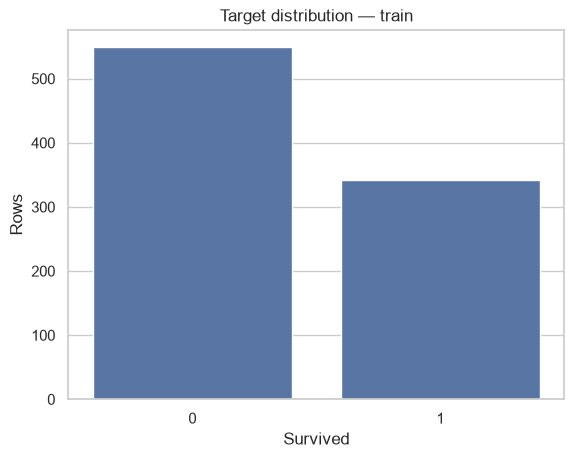

In [7]:
if ENABLE_PLOTS and TARGET is not None and TARGET in train_profile.df.columns:
    train_profile.plot_target()
    plt.show()
else:
    print("График target пропущен: ENABLE_PLOTS=False или target не настроен")

## 3. Дубликаты и ключи

In [8]:
duplicate_reports = {
    name: profile.duplicate_report()
    for name, profile in profiles.items()
}
for name, report in duplicate_reports.items():
    print(name.upper())
    display(report)

TRAIN


,dataset,rows,full_row_duplicates,key,key_missing,key_duplicates,key_unique
0,train,891,0,PassengerId,0,0,True


TEST


,dataset,rows,full_row_duplicates,key,key_missing,key_duplicates,key_unique
0,test,418,0,PassengerId,0,0,True


## 4. Пропуски

In [9]:
missing_reports = {
    name: profile.missing_report()
    for name, profile in profiles.items()
}
for name, report in missing_reports.items():
    print(name.upper())
    display(report.style.format({"missing_share": "{:.2%}"}))

TRAIN


,dataset,field,missing,missing_share
0,train,Cabin,687,77.10%
1,train,Age,177,19.87%
2,train,Embarked,2,0.22%


TEST


,dataset,field,missing,missing_share
0,test,Cabin,327,78.23%
1,test,Age,86,20.57%
2,test,Fare,1,0.24%


,field,train,test
0,Age,0.20,0.21
1,Cabin,0.77,0.78
2,Embarked,0.00,0.00
3,Fare,0.00,0.00


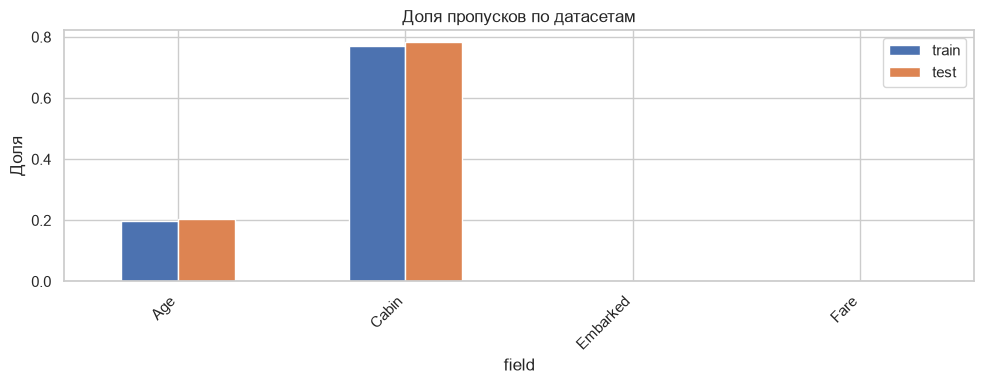

In [10]:
missing_comparison = DatasetProfiler.compare_missing(*profiles.values())
display(missing_comparison.style.format(precision=2))

if ENABLE_PLOTS and not missing_comparison.empty:
    missing_comparison.set_index("field").plot(kind="bar", figsize=(10, 4))
    plt.title("Доля пропусков по датасетам")
    plt.ylabel("Доля")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Числовые и счётные признаки

Используются только группы `numeric` и `count` из `FEATURE_GROUPS`.

In [11]:
numeric_report = train_profile.numeric_report(
    columns=numeric_features
)
display(numeric_report)

,field,count,mean,std,min,25%,50%,75%,max
0,Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
1,Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
2,SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
3,Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000


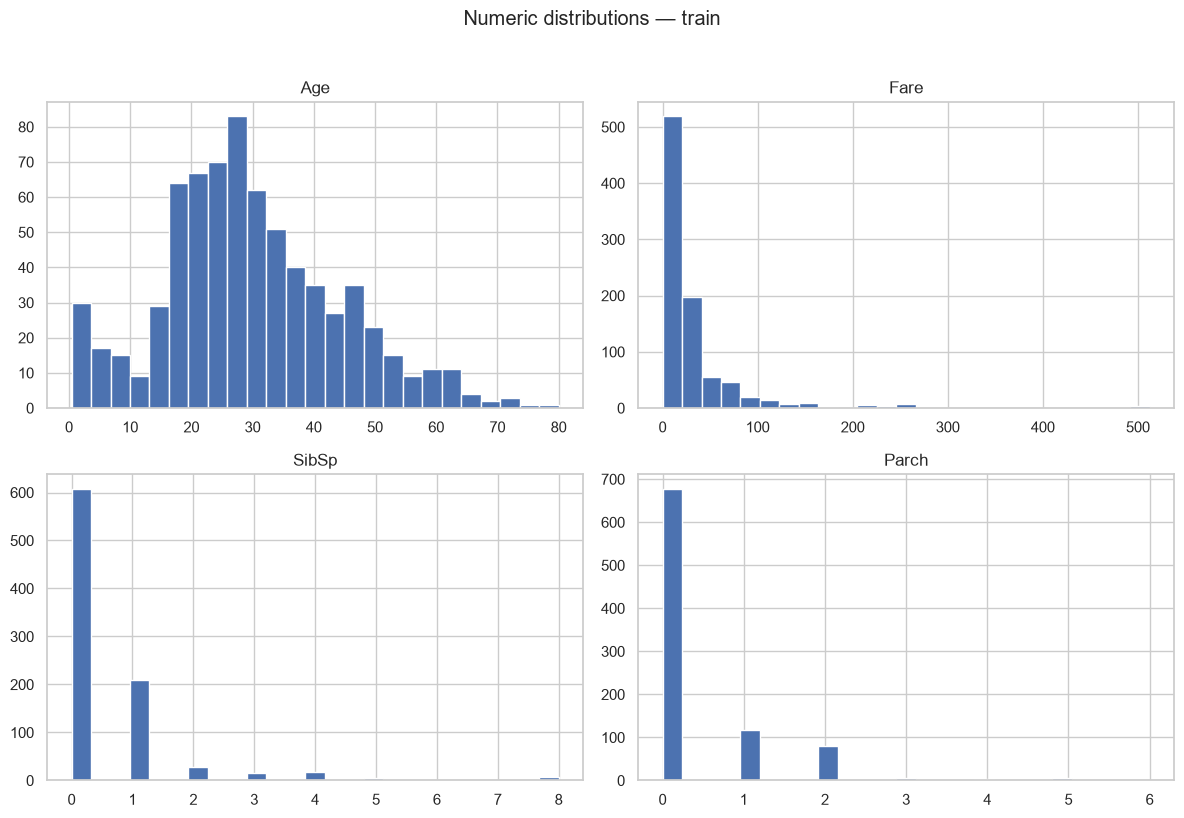

In [12]:
if ENABLE_PLOTS:
    train_profile.plot_numeric_histograms(
        columns=numeric_features
    )
    plt.show()
else:
    print("Гистограммы пропущены: ENABLE_PLOTS=False")

## 6. Категориальные и порядковые признаки

Используются только группы `categorical` и `ordinal` из `FEATURE_GROUPS`. Группы `text`, `datetime`, `identifier` и `ignored` не смешиваются с этими отчётами.

In [13]:
categorical_report = train_profile.categorical_report(
    columns=categorical_features
)
display(categorical_report)

,field,unique,most_frequent,frequency
0,Sex,2,male,577
1,Cabin,147,B96 B98,4
2,Embarked,3,S,644
3,Pclass,3,3,491


## 7. Синхронизация с документом

Следующая ячейка обновляет только автоматические блоки Snapshot, Target и качества в `docs/02_eda.md`. Интерпретации, гипотезы и ручные выводы не перезаписываются.

In [14]:
eda_blocks = build_eda_blocks(
    catalog,
    profiles,
    train_dataset=TRAIN_DATASET,
)
updated_blocks = MarkdownDocument(
    PROJECT_ROOT / "docs" / "02_eda.md"
).update_blocks(eda_blocks)

print("Обновлены блоки:", ", ".join(updated_blocks))

Обновлены блоки: eda-snapshot, eda-target, eda-quality


## 8. Что заполнить вручную

Автоматический профиль сообщает **что обнаружено**, но не объясняет **почему**. В `docs/02_eda.md` вручную зафиксируйте интерпретацию дисбаланса, причины пропусков, аномалии, leakage-кандидаты, выводы и проверяемые гипотезы.